# Global_ER_replotting v2

Combines four levels of Within/Across enrichment into one figure:
1. **cis-eQTL (unique genes)** - `Source_gene` alone, collapsed across module/program.
   The only level with a `Mixed` composition category (genes that are Within
   in some contexts and Across in others don't collapse away at this grain).
2. **unique cis-eQTL-trans-eQTL edges** - gene-pair-collapsed Fisher test.
3. **cis/trans network** - `(Source_module, Source_gene, program)` combination.

(The edge level, `p_edge_full`, is built and saved separately below but is
not part of the final 3-panel combined figure, since it uses a fold-enrichment/
permutation-null statistic rather than a Fisher odds ratio - see the
`odds_or_fold_note` in its saved metadata.)

**Important**: `Mixed` exists ONLY at the cis-eQTL (unique genes) level. The
other two levels only ever have Within-only/Across-only factors by
construction (see Methods.md) - `Mixed` should appear once in the combined
legend, sourced from the cis-eQTL panel, and is expected to be structurally
absent from the other two panels, not a missing-data problem.


# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("gridExtra"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
library(lme4)
library(parallel)
library(UpSetR)



Attaching package: ‘lme4’


The following object is masked from ‘package:generics’:

    refit




## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)


# PATH

In [3]:
master_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
global_plots_dir <- paste0(master_dir, "Global_plots/")
dir.create(global_plots_dir, recursive = TRUE, showWarnings = FALSE)
cat("Created:", global_plots_dir, "\n")


Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Global_plots/ 


# Level 1 setup: load the cis-eQTL exosome bundle's resource colors

(Used purely as the source of `resource_colors`/`resource_legend_labels_with_exosome`
for cross-level consistency - the actual "cis-eQTL" panel data now comes
from the NEW gene-level bundle further down, not from this one.)

In [4]:
cis_eqtl_bundle_path <- paste0(master_dir, "cis_eQTL_level_exosome/cis_eqtl_exosome_results_bundle.rds")
results_bundle <- readRDS(cis_eqtl_bundle_path)

plot_metadata    <- results_bundle$plot_metadata
resource_colors  <- plot_metadata$resource_colors   # named vector: CollecTRI, SCENIC_activator, SCENIC_repressor, RBP, LR, PPI, MEROPS, Exosome
resource_legend_labels_with_exosome <- c(
  "CollecTRI" = "CollecTRI", "SCENIC_activator" = "SCENIC activator", "SCENIC_repressor" = "SCENIC repressor",
  "RBP" = "RBP (POSTAR3)", "LR" = "Liana L-R", "MEROPS" = "MEROPS\nPeptidase-substrate", "PPI" = "PPI (STRING)",
  "Exosome" = "Blood exosome (healthy donor)"
)
resource_legend_labels <- resource_legend_labels_with_exosome[names(resource_legend_labels_with_exosome) != "Exosome"]

cat("Loaded resource_colors:\n")
print(resource_colors)


Loaded resource_colors:
       CollecTRI SCENIC_activator SCENIC_repressor              RBP 
       "#D55E00"         "orange"          "black"        "#CC79A7" 
              LR              PPI           MEROPS          Exosome 
       "#009E73"        "#0072B2"         "grey50"         "purple" 


# Edge level

Reconstructs `combined_results` from the 56 raw per-job curveball
permutation result files (excludes the pre-split combined SCENIC resource,
8 files - see comment below).

In [5]:
results_dir <- paste0(master_dir, "results_v2/")
result_files_all <- list.files(results_dir, pattern = "_result\\.tsv$", full.names = TRUE)
cat(length(result_files_all), "result files found on disk\n")

## EXCLUDES "SCENIC_regulon_same_dataset_single_tier" (8 files) - this is the
## pre-split combined SCENIC resource, superseded by the activator/repressor
## split (see Overhaul_finding_patterns_v11.ipynb changelog, Methods.md
## section 6). Retaining only the 56 combinations matching Methods.md's
## stated design ("12 directed + 2 undirected x 4 conditions = 56 tests total").
excluded_pattern <- "SCENIC_regulon_same_dataset_single_tier_"
result_files <- result_files_all[!grepl(excluded_pattern, basename(result_files_all), fixed = TRUE)]
cat("Remaining result files:", length(result_files), "(expect 56, per Methods.md)\n")
stopifnot(length(result_files) == 56)

edge_level_raw <- rbindlist(lapply(result_files, function(f) {
  dt <- fread(f)
  dt[, source_file := basename(f)]
  dt
}), fill = TRUE)

cat("Rows loaded:", nrow(edge_level_raw), "\n")


64 result files found on disk
Remaining result files: 56 (expect 56, per Methods.md)
Rows loaded: 56 


In [6]:
edge_level_raw[, stringency_detail := trimws(sub("\\|.*$", "", condition))]
edge_level_raw[, eqtl_condition    := trimws(sub("^.*eQTL:\\s*", "", condition))]

known_conditions <- c("Across_GWAS_colocalized", "Within_GWAS_colocalized", "Across_full", "Within_full")
stopifnot(all(edge_level_raw$eqtl_condition %in% known_conditions))

n_mismatch <- sum(!mapply(function(f, cond) endsWith(sub("_result\\.tsv$", "", f), cond),
                           edge_level_raw$source_file, edge_level_raw$eqtl_condition))
stopifnot(n_mismatch == 0)

edge_level_raw[, resource_name := analysis]


In [7]:
edge_level_raw[, edge_type := sub("_.*", "", eqtl_condition)]
edge_level_raw[, edge_type := factor(edge_type, levels = c("Within", "Across"))]

edge_level_raw[, graph_type := ifelse(grepl("GWAS_colocalized", eqtl_condition), "GWAS_colocalized", "full")]
edge_level_raw[, graph_type := factor(graph_type, levels = c("full", "GWAS_colocalized"))]

edge_level_raw[, neg_log10_p := -log10(p_enrichment)]
edge_level_raw[, fold_enrichment := observed_hits / null_mean]

resource_display_labels <- c(
  "STRING_experimental"                    = "PPI (STRING, experimental)",
  "CollecTRI"                               = "TF-target (CollecTRI)",
  "Liana"                                   = "Ligand-Receptor (Liana)",
  "POSTAR3"                                 = "RBP-target (POSTAR3)",
  "MEROPS"                                  = "Peptidase-substrate (MEROPS)",
  "SCENIC_regulon_activator_same_dataset"   = "activator TF-target (SCENIC)",
  "SCENIC_regulon_repressor_same_dataset"   = "repressor TF-target (SCENIC)"
)
stopifnot(all(edge_level_raw$resource_name %in% names(resource_display_labels)))
edge_level_raw[, resource_display := resource_display_labels[resource_name]]

direction_display_labels <- c(
  "forward"    = "cis-eQTL \u2192 trans-eQTL",
  "reverse"    = "trans-eQTL \u2192 cis-eQTL",
  "undirected" = "Undirected (PPI)"
)
edge_level_raw[, direction_display := direction_display_labels[direction]]

## Map the two literal stringency_detail strings for STRING to strict/lenient
edge_level_raw[, stringency_label := fcase(
  resource_name == "STRING_experimental" & stringency_detail == "score_experimentally_determined_interaction >= 0.4", "strict",
  resource_name == "STRING_experimental" & grepl("MINUS", stringency_detail, fixed = TRUE), "lenient_band_0.1_to_0.4",
  default = "single_tier"
)]

n_testable <- sum(!edge_level_raw$is_untestable)
edge_level_raw[, p_adj_BH := NA_real_]
edge_level_raw[is_untestable == FALSE, p_adj_BH := p.adjust(p_enrichment, method = "BH")]
edge_level_raw[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]

combined_results <- edge_level_raw
cat("Testable:", n_testable, "/", nrow(combined_results), "\n")


Testable: 49 / 56 


In [8]:
## Exact Poisson CI on observed_hits, converted to a CI on fold_enrichment
poisson_ci_fold <- function(observed, null_mean, conf_level = 0.95) {
  alpha <- 1 - conf_level
  lower_count <- ifelse(observed == 0, 0, qchisq(alpha / 2, 2 * observed) / 2)
  upper_count <- qchisq(1 - alpha / 2, 2 * (observed + 1)) / 2
  fold_lo <- ifelse(null_mean > 0, lower_count / null_mean, NA_real_)
  fold_hi <- ifelse(null_mean > 0, upper_count / null_mean, NA_real_)
  list(fold_ci_low = fold_lo, fold_ci_high = fold_hi)
}

ci_result <- poisson_ci_fold(combined_results$observed_hits, combined_results$null_mean)
combined_results[, fold_ci_low  := ci_result$fold_ci_low]
combined_results[, fold_ci_high := ci_result$fold_ci_high]


In [9]:
edge_level_full <- combined_results[graph_type == "full"]
cat("Rows after restricting to graph_type == 'full':", nrow(edge_level_full), "/", nrow(combined_results), "\n")

edge_resource_key_map <- c(
  "CollecTRI"                              = "CollecTRI",
  "SCENIC_regulon_activator_same_dataset"  = "SCENIC_activator",
  "SCENIC_regulon_repressor_same_dataset"  = "SCENIC_repressor",
  "POSTAR3"                                 = "RBP",
  "Liana"                                   = "LR",
  "MEROPS"                                  = "MEROPS",
  "STRING_experimental"                     = "PPI"
)
stopifnot(all(edge_level_full$resource_name %in% names(edge_resource_key_map)))
edge_level_full[, resource_key := edge_resource_key_map[resource_name]]


Rows after restricting to graph_type == 'full': 28 / 56 


## Row labels / order (recycled verbatim; this is the master row-order
spec reused, verbatim, for every subsequent level in this notebook)

In [10]:
ppi_score_text <- fcase(
  edge_level_full$stringency_label == "strict", "score >= 0.4",
  edge_level_full$stringency_label == "lenient_band_0.1_to_0.4", "0.1 < score <= 0.4",
  default = NA_character_
)

edge_level_full[, row_label := fifelse(
  resource_key == "PPI",
  paste(resource_display, ppi_score_text, direction_display, sep = "\n"),
  paste(resource_display, direction_display, sep = "\n")
)]

row_order_top_to_bottom <- c(
  "TF-target (CollecTRI)\ncis-eQTL \u2192 trans-eQTL",
  "TF-target (CollecTRI)\ntrans-eQTL \u2192 cis-eQTL",
  "activator TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "activator TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "repressor TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "repressor TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "RBP-target (POSTAR3)\ncis-eQTL \u2192 trans-eQTL",
  "RBP-target (POSTAR3)\ntrans-eQTL \u2192 cis-eQTL",
  "Ligand-Receptor (Liana)\ncis-eQTL \u2192 trans-eQTL",
  "Ligand-Receptor (Liana)\ntrans-eQTL \u2192 cis-eQTL",
  "Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL",
  "Peptidase-substrate (MEROPS)\ntrans-eQTL \u2192 cis-eQTL",
  "PPI (STRING, experimental)\n0.1 < score <= 0.4\nUndirected (PPI)",
  "PPI (STRING, experimental)\nscore >= 0.4\nUndirected (PPI)",
  "Blood exosome\n(healthy donor)"
)

cat("Rows in edge_level_full NOT covered by the explicit order (should be empty):\n")
print(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(edge_level_full$row_label), row_order_top_to_bottom)) == 0)

axis_limits_bottom_to_top_with_exosome <- rev(row_order_top_to_bottom)
axis_limits_bottom_to_top <- axis_limits_bottom_to_top_with_exosome[
  axis_limits_bottom_to_top_with_exosome != "Blood exosome\n(healthy donor)"
]


Rows in edge_level_full NOT covered by the explicit order (should be empty):
character(0)


## p_edge_full

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

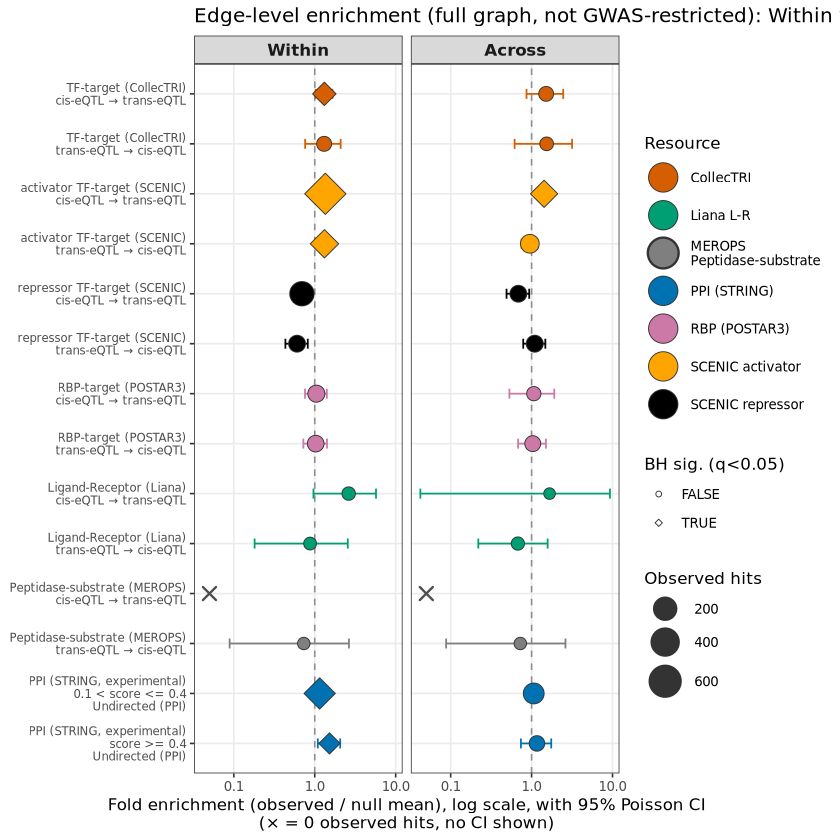

In [11]:
x_axis_floor_edge <- 0.05

edge_level_full[, is_zero_hit := !is.na(fold_enrichment) & observed_hits == 0]
edge_level_full[, x_plot_final := fifelse(is_zero_hit, x_axis_floor_edge, fold_enrichment)]
edge_level_full[, ci_low_plot  := fifelse(is_zero_hit, NA_real_, fold_ci_low)]
edge_level_full[, ci_high_plot := fifelse(is_zero_hit, NA_real_, fold_ci_high)]

p_edge_full <- ggplot(edge_level_full[!is.na(fold_enrichment)],
                       aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = edge_level_full[!is.na(fold_enrichment) & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_key, shape = sig_BH_05),
    color = "grey20", stroke = 0.4
  ) +
  geom_point(
    data = edge_level_full[!is.na(fold_enrichment) & is_zero_hit == TRUE],
    aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  facet_grid(cols = vars(edge_type)) +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Edge-level enrichment (full graph, not GWAS-restricted): Within vs Across"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 10, face = "bold"),
    panel.grid.minor = element_blank(),
    legend.text = element_text(size = 8)
  ) +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(global_plots_dir, "edge_level_full_within_across_facet.png"), p_edge_full,
       width = 10, height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(global_plots_dir, "edge_level_full_within_across_facet.pdf"), p_edge_full,
       width = 10, height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_edge_full


### SAVE edge level

In [12]:
edge_level_plot_metadata <- list(
  resource_colors = resource_colors, resource_legend_labels = resource_legend_labels,
  row_order_top_to_bottom = row_order_top_to_bottom, axis_limits_bottom_to_top = axis_limits_bottom_to_top,
  facet_variable = "edge_type", subset_applied = "graph_type == 'full' (GWAS_colocalized excluded)",
  x_variable = "fold_enrichment (observed_hits / null_mean)",
  ci_method = "Exact Poisson CI (qchisq-based) on observed_hits, divided by null_mean; NA where null_mean == 0",
  odds_or_fold_note = "This is fold_enrichment from the curveball permutation null, NOT a Fisher odds ratio - not directly comparable in magnitude to the other levels' odds ratios, only in direction/significance.",
  source_cis_eqtl_bundle = cis_eqtl_bundle_path, generated_on = Sys.time(), r_session = capture.output(sessionInfo())
)
edge_level_full_bundle <- list(edge_level_full = edge_level_full, plot_metadata = edge_level_plot_metadata)
saveRDS(edge_level_full_bundle, file = paste0(global_plots_dir, "edge_level_full_results_bundle.rds"))
fwrite(edge_level_full, paste0(global_plots_dir, "edge_level_full_results.tsv"), sep = "\t")
cat("Saved edge-level bundle.\n")


Saved edge-level bundle.


# Level: unique cis-eQTL-trans-eQTL edges (gene-pair-collapsed Fisher)

In [13]:
coverage_dir <- paste0(master_dir, "coverage_analysis/")
gene_pair_fisher_path <- paste0(coverage_dir, "forest_plot_collapsed_fisher_data.rds")
gene_pair_fisher_raw <- readRDS(gene_pair_fisher_path)

cat("Dimensions:", paste(dim(gene_pair_fisher_raw), collapse = " x "), "\n")
print(names(gene_pair_fisher_raw))


Dimensions: 13 x 16 
 [1] "resource"           "label"              "status"            
 [4] "n_pairs_within"     "n_pairs_across"     "pairs_annot_within"
 [7] "pairs_annot_across" "odds_ratio"         "ci_low"            
[10] "ci_high"            "p_value"            "p_adj_BH"          
[13] "sig_BH_05"          "resource_display"   "row_label"         
[16] "total_annot_pairs" 


In [14]:
gene_pair_fisher_raw[, direction := fcase(
  grepl("^Source_", label), "forward",
  grepl("^Target_", label), "reverse",
  resource == "STRING_experimental", "undirected",
  default = NA_character_
)]
stopifnot(!any(is.na(gene_pair_fisher_raw$direction)))

gene_pair_fisher_raw[, ppi_score_text_gp := fcase(
  grepl(">=0.4", label, fixed = TRUE), "score >= 0.4",
  grepl(">=0.1 <0.4", label, fixed = TRUE), "0.1 < score <= 0.4",
  default = NA_character_
)]

gene_pair_fisher_raw[, row_label := fifelse(
  resource == "STRING_experimental",
  paste(resource_display, ppi_score_text_gp, direction_display_labels["undirected"], sep = "\n"),
  paste(resource_display, direction_display_labels[direction], sep = "\n")
)]

cat("gene_pair row_labels NOT in the recycled order (should be empty):\n")
print(setdiff(unique(gene_pair_fisher_raw$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(gene_pair_fisher_raw$row_label), row_order_top_to_bottom)) == 0)

gene_pair_fisher_raw[, resource_key := edge_resource_key_map[resource]]
gene_pair_fisher_raw[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]


gene_pair row_labels NOT in the recycled order (should be empty):
character(0)


# Level: cis/trans network `(Source_module, Source_gene, program)`

In [15]:
cis_trans_network_bundle <- readRDS(paste0(master_dir, "Factor_ER/cis_trans_network_results_bundle.rds"))

ctn_odds_data <- cis_trans_network_bundle$fisher_only
ctn_comp_data <- cis_trans_network_bundle$composition_factor_long
total_pairs_n <- cis_trans_network_bundle$plot_metadata$total_n  # placeholder, overwritten below with the real edge-count total


In [16]:
## Real total for the gene-pair level: unique (Source_gene, Target_gene) pairs
whole_eqtl_annotated <- readRDS(paste0(master_dir, "whole_eqtl_annotated.rds"))
total_pairs_n <- uniqueN(whole_eqtl_annotated[, .(Source_gene, Target_gene)])
cat("total_pairs_n:", total_pairs_n, "\n")

## Exosome NA placeholder for cis/trans network (never tested there)
exosome_na_odds_ctn <- data.table(
  category = "has_exosome_blood_healthy",
  odds_ratio = NA_real_, ci_low = NA_real_, ci_high = NA_real_, p_adj_BH = NA_real_,
  n_pos = NA_integer_, resource_key = "Exosome", row_label = "Blood exosome\n(healthy donor)",
  status = NA_character_, sig_BH_05 = NA, is_zero_hit = FALSE,
  x_plot_final = NA_real_, ci_low_plot = NA_real_, ci_high_plot = NA_real_, is_not_applicable = TRUE
)
ctn_odds_data <- rbind(ctn_odds_data, exosome_na_odds_ctn, fill = TRUE)

exosome_na_comp_ctn <- data.table(
  row_label = "Blood exosome\n(healthy donor)", n_total_pos = NA_integer_,
  composition_type = factor(c("Within", "Across"), levels = c("Within", "Across")), pct = NA_real_
)
ctn_comp_data <- rbind(ctn_comp_data, exosome_na_comp_ctn, fill = TRUE)


total_pairs_n: 58434 


# Level: cis-eQTL (unique genes) - the NEW distinct level

Loaded from `cis_eQTL_gene_level_enrichment.ipynb`'s saved bundle. This is
DISTINCT from the `(Source_module, Source_gene, program)` "cis/trans
network" grain above - collapsed to `Source_gene` alone. It is the ONLY
level with a `Mixed` composition category and TWO Fisher comparisons
(Across-only vs Within-only, Mixed vs Within-only), reflected as two
internal facets in its odds-ratio panel.

In [17]:
cis_eqtl_gene_level_bundle <- readRDS(paste0(master_dir, "cis_eQTL_gene_level/cis_eqtl_gene_level_bundle.rds"))
cat(cis_eqtl_gene_level_bundle$plot_metadata$mixed_category_note, "\n")

ce_odds_data <- cis_eqtl_gene_level_bundle$ce_odds_data
ce_comp_data <- copy(cis_eqtl_gene_level_bundle$ce_comp_data)

## Relabel "Within-only"/"Across-only" -> "Within"/"Across" so the composition
## legend merges cleanly with the two-category legend used by the other
## levels. "Mixed" keeps its own name, unique to this level.
ce_comp_data[, composition_type := as.character(composition_type)]
ce_comp_data[composition_type == "Within-only", composition_type := "Within"]
ce_comp_data[composition_type == "Across-only", composition_type := "Across"]
ce_comp_data[, composition_type := factor(composition_type, levels = c("Within", "Across", "Mixed"))]

within_across_colors <- c("Within" = "#4C72B0", "Across" = "#DD8452")
within_across_mixed_colors <- c("Within" = "#4C72B0", "Across" = "#DD8452", "Mixed" = "#55A868")

cat("cis-eQTL gene-level row_labels NOT in the shared axis order (should be empty):\n")
print(setdiff(unique(ce_odds_data$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(ce_odds_data$row_label), row_order_top_to_bottom)) == 0)

total_cis_eqtl_gene_n <- cis_eqtl_gene_level_bundle$plot_metadata$total_n
cat("total_cis_eqtl_gene_n:", total_cis_eqtl_gene_n, "\n")


The 'Mixed' composition category exists ONLY at this level (unique cis-eQTL genes). The gene-pair-collapsed level and the cis/trans network level both classify only Within-only/Across-only factors, with zero Mixed rows by construction (see Methods.md). When building a combined legend across all three levels, 'Mixed' should be included once (sourced from this level) and NOT expected to appear in, or be silently dropped from, the other two levels' color scales. 
cis-eQTL gene-level row_labels NOT in the shared axis order (should be empty):
character(0)
total_cis_eqtl_gene_n: 1152 


# Build the four panel-building helpers

`build_odds_panel()`/`build_comp_panel()` are the generic (single-comparison,
2-color) versions used for the gene-pair and cis/trans network levels. The
cis-eQTL (unique genes) level is built separately just below since it has
an internal facet and a 3-color composition.

In [18]:
build_odds_panel <- function(dt, title_text) {
  if (!"is_not_applicable" %in% names(dt)) dt[, is_not_applicable := FALSE]
  dt[is.na(is_not_applicable), is_not_applicable := is.na(odds_ratio)]

  point_filter <- dt[is_zero_hit == FALSE & is_not_applicable == FALSE]

  ggplot(dt, aes(x = x_plot_final, y = row_label)) +
    geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
    geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                  orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
    geom_point(data = point_filter, aes(fill = resource_key, shape = sig_BH_05),
               color = "grey20", stroke = 0.4, size = 5) +
    geom_point(data = dt[is_zero_hit == TRUE], aes(fill = resource_key),
               shape = 4, size = 3, color = "grey30", stroke = 1) +
    geom_text(data = dt[is_not_applicable == TRUE], aes(x = 1), label = "NA",
              color = "grey40", size = 3, fontface = "italic") +
    scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
    scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels_with_exosome) +
    scale_color_manual(values = resource_colors, guide = "none") +
    scale_x_log10() +
    scale_y_discrete(limits = axis_limits_bottom_to_top_with_exosome) +
    labs(x = "Odds ratio (Across vs Within), log scale, with 95% CI\n(\u00d7 = 0 hits; NA = not applicable)",
         y = NULL, title = title_text) +
    theme_bw(base_size = 10) +
    theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(),
          legend.position = "bottom", plot.title = element_text(size = 9, face = "bold")) +
    guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))
}

build_comp_panel <- function(dt) {
  na_rows <- unique(dt[is.na(pct), .(row_label)])
  ggplot(dt, aes(x = pct, y = row_label, fill = composition_type)) +
    geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
    geom_text(
      data = unique(dt[!is.na(n_total_pos), .(row_label, n_total_pos)]),
      aes(x = 50, y = row_label, label = n_total_pos),
      inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold"
    ) +
    geom_text(
      data = na_rows, aes(x = 50, y = row_label), label = "NA",
      inherit.aes = FALSE, color = "grey40", size = 3, fontface = "italic"
    ) +
    scale_fill_manual(values = within_across_colors, name = "Composition") +
    scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100),
                        expand = expansion(mult = c(0, 0.02))) +
    scale_y_discrete(limits = axis_limits_bottom_to_top_with_exosome) +
    labs(x = "% Within vs Across", y = NULL) +
    theme_bw(base_size = 10) +
    theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
          panel.grid.minor = element_blank(), legend.position = "bottom")
}


## Build all six panels

In [19]:
## --- cis-eQTL (unique genes): internal 2-facet odds panel, 3-color composition ---
p_odds_ce <- ggplot(ce_odds_data, aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(data = ce_odds_data[is_zero_hit == FALSE & is_not_applicable == FALSE],
             aes(fill = resource_key, shape = sig_BH_05), color = "grey20", stroke = 0.4, size = 5) +
  geom_point(data = ce_odds_data[is_zero_hit == TRUE],
             aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1) +
  geom_text(data = ce_odds_data[is_not_applicable == TRUE], aes(x = 1), label = "NA",
            color = "grey40", size = 3, fontface = "italic") +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels_with_exosome) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top_with_exosome) +
  facet_grid(cols = vars(comparison)) +
  labs(x = "Odds ratio, log scale, with 95% CI\n(\u00d7 = 0 hits; NA = not applicable)",
       y = NULL, title = paste0("cis-eQTL (unique genes, total N = ", total_cis_eqtl_gene_n, ")")) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(),
        legend.position = "bottom", plot.title = element_text(size = 9, face = "bold"),
        strip.text = element_text(size = 8, face = "bold"))

p_comp_ce <- ggplot(ce_comp_data, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(
    data = unique(ce_comp_data[!is.na(n_total_pos), .(row_label, n_total_pos)]),
    aes(x = 50, y = row_label, label = n_total_pos),
    inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold"
  ) +
  scale_fill_manual(values = within_across_mixed_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = axis_limits_bottom_to_top_with_exosome) +
  labs(x = "% Within vs Across vs Mixed", y = NULL) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(), legend.position = "bottom")

## --- unique cis-eQTL-trans-eQTL edges (gene-pair) ---
gp_odds_data <- gene_pair_fisher_raw[, .(row_label, resource_key, odds_ratio, ci_low, ci_high, sig_BH_05,
                                           n_pos = pairs_annot_within + pairs_annot_across)]
gp_odds_data[, is_zero_hit := !is.na(odds_ratio) & (odds_ratio == 0 | !is.finite(odds_ratio))]
gp_odds_data[, is_not_applicable := FALSE]

## Explicit NA rows: MEROPS-forward (never existed at this grain) + exosome (not applicable here)
merops_forward_na_row <- data.table(
  row_label = "Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL",
  resource_key = "MEROPS", odds_ratio = NA_real_, ci_low = NA_real_, ci_high = NA_real_,
  sig_BH_05 = NA, n_pos = NA_integer_, is_zero_hit = FALSE, is_not_applicable = TRUE
)
exosome_na_row_gp <- data.table(
  row_label = "Blood exosome\n(healthy donor)", resource_key = "Exosome",
  odds_ratio = NA_real_, ci_low = NA_real_, ci_high = NA_real_,
  sig_BH_05 = NA, n_pos = NA_integer_, is_zero_hit = FALSE, is_not_applicable = TRUE
)
gp_odds_data <- rbind(gp_odds_data, merops_forward_na_row, exosome_na_row_gp, fill = TRUE)

x_axis_floor_or <- 0.05
gp_odds_data[, x_plot_final := fifelse(is_zero_hit, x_axis_floor_or, odds_ratio)]
gp_odds_data[, ci_low_plot  := fifelse(is_zero_hit, NA_real_, ci_low)]
gp_odds_data[, ci_high_plot := fifelse(is_zero_hit, NA_real_, ci_high)]

gp_comp_data <- rbind(
  gene_pair_fisher_raw[, .(row_label, n_total_pos = pairs_annot_within + pairs_annot_across,
                             composition_type = "Within", pct = 100 * pairs_annot_within / (pairs_annot_within + pairs_annot_across))],
  gene_pair_fisher_raw[, .(row_label, n_total_pos = pairs_annot_within + pairs_annot_across,
                             composition_type = "Across", pct = 100 * pairs_annot_across / (pairs_annot_within + pairs_annot_across))]
)
gp_comp_data <- rbind(gp_comp_data,
  data.table(row_label = c("Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL", "Blood exosome\n(healthy donor)"),
             n_total_pos = NA_integer_, composition_type = "Within", pct = NA_real_),
  data.table(row_label = c("Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL", "Blood exosome\n(healthy donor)"),
             n_total_pos = NA_integer_, composition_type = "Across", pct = NA_real_)
)
gp_comp_data[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

p_odds_gp  <- build_odds_panel(gp_odds_data,  paste0("unique cis-eQTL-trans-eQTL edges (total N = ", total_pairs_n, ")")) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())
p_odds_ctn <- build_odds_panel(ctn_odds_data, paste0("cis/trans network (total N = ", cis_trans_network_bundle$plot_metadata$total_n, ")")) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())
p_comp_gp  <- build_comp_panel(gp_comp_data)
p_comp_ctn <- build_comp_panel(ctn_comp_data)


## Combine: single merged legend, cowplot panel-width alignment

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+

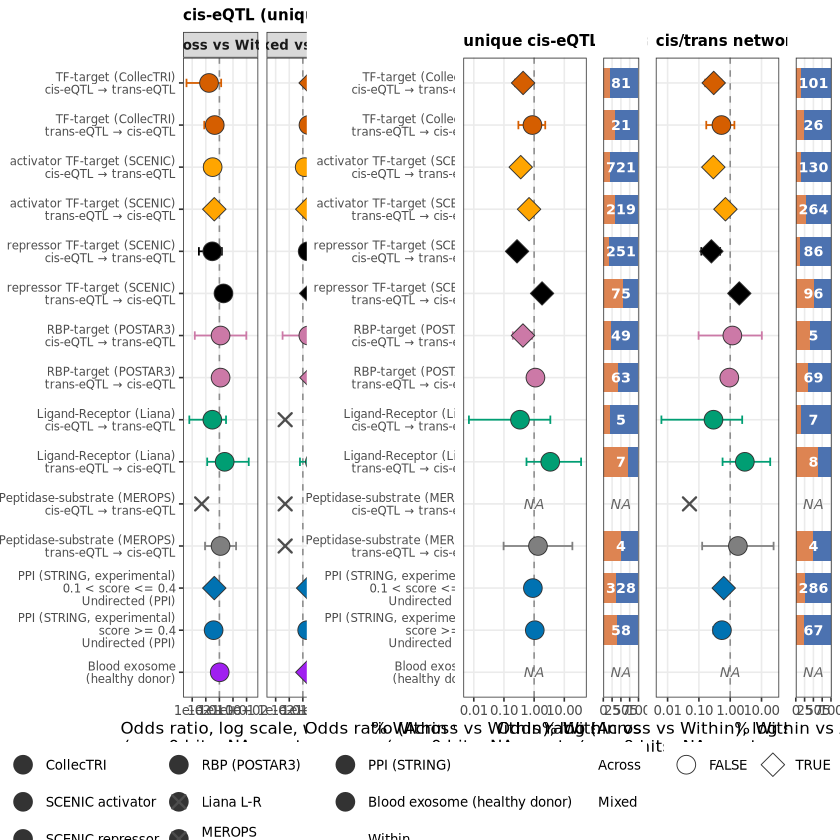

In [23]:
strip_legend <- function(p) p + theme(legend.position = "none")

panels_no_legend <- list(
  strip_legend(p_odds_ce),  strip_legend(p_comp_ce),
  strip_legend(p_odds_gp),  strip_legend(p_comp_gp),
  strip_legend(p_odds_ctn), strip_legend(p_comp_ctn)
)

## ce's odds panel has 2 internal facets - widened relative to gp/ctn's
## single-panel odds plots. NOTE: this ratio is a visual estimate, not
## derived - tune after seeing the actual render.
main_grid <- plot_grid(
  plotlist = panels_no_legend,
  ncol = 6, align = "h", axis = "tb",
  rel_widths = c(5, 1.5, 2, 0.75, 2, 0.75)
)

## Single merged legend: Resource (8, incl. Exosome), BH-sig shape,
## Composition (3, incl. Mixed - unique to the cis-eQTL panel).
p_legend_source <- p_odds_ce +
  geom_col(data = data.table(x = 1, y = "Within", composition_type = c("Within", "Across", "Mixed")),
            aes(x = x, y = y, fill = composition_type), inherit.aes = FALSE, alpha = 0) +
  scale_fill_manual(
    name = NULL,
    values = c(resource_colors, within_across_mixed_colors),
    breaks = c(names(resource_legend_labels_with_exosome), "Within", "Across", "Mixed"),
    labels = c(resource_legend_labels_with_exosome, "Within", "Across", "Mixed")
  ) +
  theme(legend.position = "bottom", legend.title = element_blank())

single_legend <- get_legend(p_legend_source)

p_three_levels <- plot_grid(main_grid, single_legend, ncol = 1, rel_heights = c(10, 1))

ggsave(paste0(global_plots_dir, "three_levels_combined.png"), p_three_levels,
       width = 22, height = max(4, 0.35 * length(axis_limits_bottom_to_top_with_exosome) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(global_plots_dir, "three_levels_combined.pdf"), p_three_levels,
       width = 22, height = max(4, 0.35 * length(axis_limits_bottom_to_top_with_exosome) + 1.5), bg = "white")

p_three_levels


## New plots

cis-eQTL composition rows with NA pct:
                                             row_label
                                                <char>
1: Peptidase-substrate (MEROPS)\ncis-eQTL → trans-eQTL


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

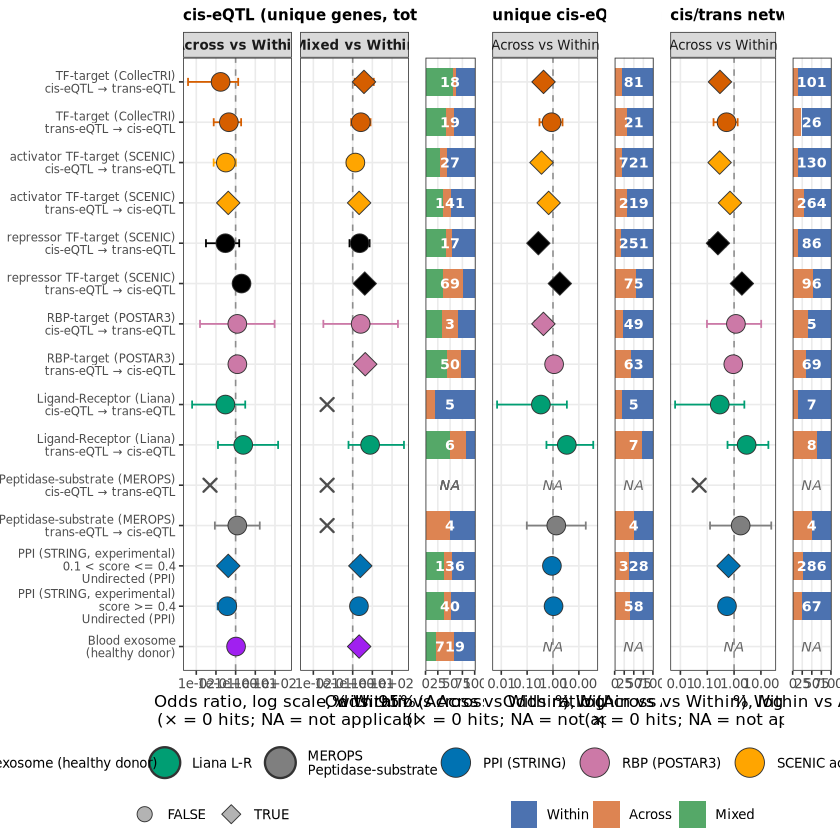

In [26]:
## Row 1: Resource fill legend (8 swatches, single row) - extracted from
## p_odds_ce directly, so it inherits the ACTUAL colors used in the plot
## rather than a re-declared scale that can silently drop them.
legend_row1 <- get_legend(
  p_odds_ce + guides(fill = guide_legend(nrow = 1, override.aes = list(size = 8, shape = 21, colour = "grey20")),
                       shape = "none") +
    theme(legend.position = "bottom", legend.title = element_blank())
)

## Row 2, left: BH-significance shape legend
legend_shape <- get_legend(
  p_odds_ce + guides(fill = "none", shape = guide_legend(nrow = 1, override.aes = list(size = 4, fill = "grey70"))) +
    theme(legend.position = "bottom", legend.title = element_blank())
)

## Row 2, right: Composition legend (Within/Across/Mixed) - from p_comp_ce directly
legend_comp <- get_legend(
  p_comp_ce + guides(fill = guide_legend(nrow = 1)) +
    theme(legend.position = "bottom", legend.title = element_blank())
)

legend_row2 <- plot_grid(legend_shape, legend_comp, nrow = 1)
single_legend <- plot_grid(legend_row1, legend_row2, ncol = 1)

p_comp_ce <- p_comp_ce + theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())

ce_comp_na_rows <- unique(ce_comp_data[is.na(pct), .(row_label)])
cat("cis-eQTL composition rows with NA pct:\n")
print(ce_comp_na_rows)

p_comp_ce <- p_comp_ce +
  geom_text(data = ce_comp_na_rows, aes(x = 50, y = row_label), label = "NA",
             inherit.aes = FALSE, color = "grey40", size = 3, fontface = "italic")

gp_odds_data[, comparison_label := "Across vs Within"]
ctn_odds_data[, comparison_label := "Across vs Within"]

p_odds_gp  <- build_odds_panel(gp_odds_data,  paste0("unique cis-eQTL-trans-eQTL edges (total N = ", total_pairs_n, ")")) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank()) +
  facet_grid(cols = vars(comparison_label))
p_odds_ctn <- build_odds_panel(ctn_odds_data, paste0("cis/trans network (total N = ", cis_trans_network_bundle$plot_metadata$total_n, ")")) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank()) +
  facet_grid(cols = vars(comparison_label))


panels_no_legend <- list(
  strip_legend(p_odds_ce),  strip_legend(p_comp_ce),
  strip_legend(p_odds_gp),  strip_legend(p_comp_gp),
  strip_legend(p_odds_ctn), strip_legend(p_comp_ctn)
)

main_grid <- plot_grid(
  plotlist = panels_no_legend,
  ncol = 6, align = "h", axis = "tb",
  rel_widths = c(7.5, 1.2, 2.2, 1, 2.2, 1)
)

p_three_levels <- plot_grid(main_grid, single_legend, ncol = 1, rel_heights = c(10, 1.4))

## A4 portrait = 210 x 297 mm; 4mm margin each side -> usable 202 x 289 mm
ggsave(paste0(global_plots_dir, "three_levels_combined.png"), p_three_levels,
       width = 202, height = 145, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "three_levels_combined.pdf"), p_three_levels,
       width = 202, height = 145, units = "mm", bg = "white")

p_three_levels


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,

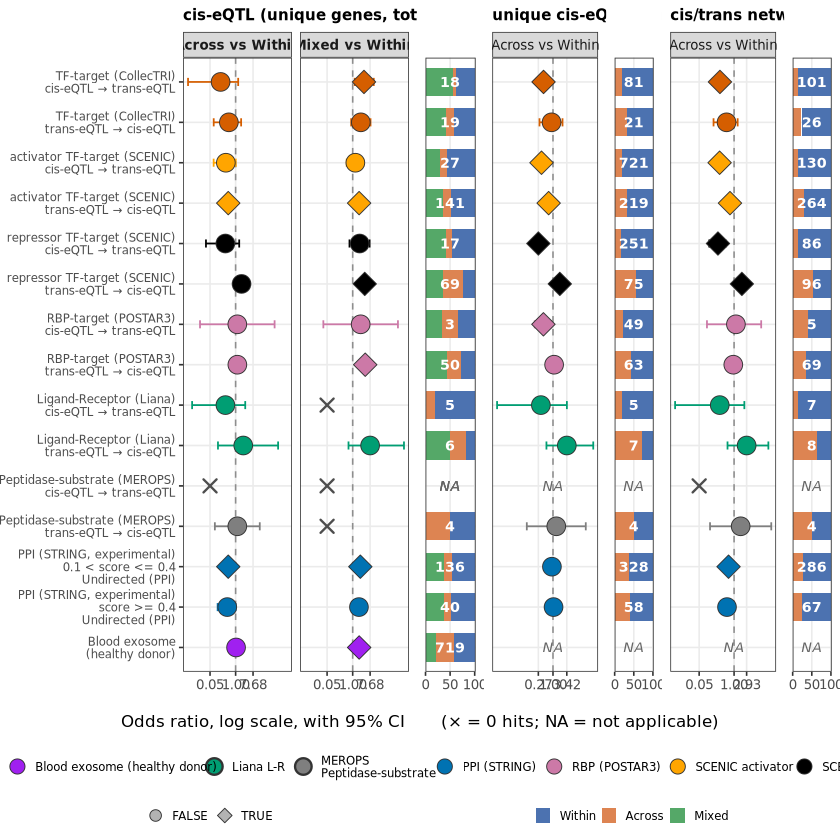

In [31]:
shared_odds_xlab <- "Odds ratio, log scale, with 95% CI\n(\u00d7 = 0 hits; NA = not applicable)"

p_odds_ce  <- p_odds_ce  + labs(x = NULL)
p_odds_gp  <- p_odds_gp  + labs(x = NULL)
p_odds_ctn <- p_odds_ctn + labs(x = NULL)
p_comp_ce  <- p_comp_ce  + labs(x = NULL)
p_comp_gp  <- p_comp_gp  + labs(x = NULL)
p_comp_ctn <- p_comp_ctn + labs(x = NULL)

## Compute 3 breaks (data min, 1, data max) per panel, since each panel has
## a different odds-ratio range - a single shared break set doesn't fit all.
make_min1max_breaks <- function(x_vals) {
  x_vals <- x_vals[is.finite(x_vals) & !is.na(x_vals)]
  if (length(x_vals) == 0) return(c(0.1, 1, 10))
  sort(unique(c(min(x_vals), 1, max(x_vals))))
}

breaks_ce  <- make_min1max_breaks(ce_odds_data$x_plot_final)
breaks_gp  <- make_min1max_breaks(gp_odds_data$x_plot_final)
breaks_ctn <- make_min1max_breaks(ctn_odds_data$x_plot_final)

label_fmt <- scales::label_number(accuracy = 0.01)

p_odds_ce  <- p_odds_ce  + scale_x_log10(breaks = breaks_ce,  labels = label_fmt(breaks_ce))
p_odds_gp  <- p_odds_gp  + scale_x_log10(breaks = breaks_gp,  labels = label_fmt(breaks_gp))
p_odds_ctn <- p_odds_ctn + scale_x_log10(breaks = breaks_ctn, labels = label_fmt(breaks_ctn))



p_comp_ce  <- p_comp_ce  + scale_x_continuous(limits = c(0, 100), breaks = c(0, 50, 100), expand = expansion(mult = c(0, 0.02)))
p_comp_gp  <- p_comp_gp  + scale_x_continuous(limits = c(0, 100), breaks = c(0, 50, 100), expand = expansion(mult = c(0, 0.02)))
p_comp_ctn <- p_comp_ctn + scale_x_continuous(limits = c(0, 100), breaks = c(0, 50, 100), expand = expansion(mult = c(0, 0.02)))

panels_no_legend <- list(
  strip_legend(p_odds_ce),  strip_legend(p_comp_ce),
  strip_legend(p_odds_gp),  strip_legend(p_comp_gp),
  strip_legend(p_odds_ctn), strip_legend(p_comp_ctn)
)

main_grid <- plot_grid(
  plotlist = panels_no_legend,
  ncol = 6, align = "h", axis = "tb",
  rel_widths = c(7.5, 1.2, 2.2, 1, 2.2, 1)
)

## One shared x-axis title spanning the odds-ratio panels only (not the
## composition/percentage panels, which keep no x-title at all per your
## earlier request to declutter those) - a single ggdraw text label placed
## under the full grid.
shared_odds_xlab_grob <- ggdraw() +
  draw_label("Odds ratio, log scale, with 95% CI\t(\u00d7 = 0 hits; NA = not applicable)",
             size = 10, fontface = "plain")

legend_row1 <- get_legend(
  p_odds_ce + guides(fill = guide_legend(nrow = 1, override.aes = list(size = 4, shape = 21, colour = "grey20")),
                       shape = "none") +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"),
          legend.spacing.x = unit(0.15, "cm"))
)

legend_shape <- get_legend(
  p_odds_ce + guides(fill = "none", shape = guide_legend(nrow = 1, override.aes = list(size = 3, fill = "grey70"))) +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)

legend_comp <- get_legend(
  p_comp_ce + guides(fill = guide_legend(nrow = 1)) +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)

legend_row2 <- plot_grid(legend_shape, legend_comp, nrow = 1)
single_legend <- plot_grid(legend_row1, legend_row2, ncol = 1)

p_three_levels <- plot_grid(
  main_grid,
  shared_odds_xlab_grob,
  single_legend,
  ncol = 1,
  rel_heights = c(10, 0.6, 1.4)
)

ggsave(paste0(global_plots_dir, "three_levels_combined.png"), p_three_levels,
       width = 202, height = 145, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "three_levels_combined.pdf"), p_three_levels,
       width = 202, height = 145, units = "mm", bg = "white")

p_three_levels

# Full numeric summary and save

# Patters plot

## Read in data

In [33]:
## =============================================================================
## Pattern classification level: loaded from the saved pattern_or_results
## table (built in Overhaul_finding_patterns_v11.ipynb's odds-ratio section),
## NOT re-derived here - this notebook only replots it.
## =============================================================================
pattern_stats_dir <- paste0(master_dir, "Patterns_in_factors_refined/pattern_stats/")
pattern_or_results <- readRDS(paste0(pattern_stats_dir, "pattern_within_across_odds_ratio.rds"))

cat("pattern_or_results loaded:", nrow(pattern_or_results), "rows\n")
print(names(pattern_or_results))
print(pattern_or_results[order(p_value)])

pattern_or_results loaded: 7 rows
 [1] "pattern"           "status"            "n_in_pattern"     
 [4] "n_background"      "across_in_pattern" "within_in_pattern"
 [7] "across_background" "within_background" "odds_ratio"       
[10] "ci_low"            "ci_high"           "p_value"          
[13] "p_adj_BH"          "sig_BH_05"         "is_degenerate"    
[16] "row_label"        
                      pattern status n_in_pattern n_background
                       <char> <char>        <int>        <int>
1:         TF_direct_cis_eQTL     ok          200          303
2:             PPI_TF_cascade     ok           18          485
3:                PPI_lenient     ok          211          292
4:       Liana_LR_interaction     ok           15          488
5: MEROPS_peptidase_substrate     ok            4          499
6:                 PPI_strict     ok           51          452
7:        RBP_direct_cis_eQTL     ok            5          498
   across_in_pattern within_in_pattern across_bac

## rebuild pattern colors

In [34]:
pattern_colors <- c(
  "TF_direct_cis_eQTL"         = palettes$vibrant$blue,
  "PPI_strict"                 = palettes$vibrant$vermillion,
  "PPI_lenient"                = palettes$vibrant$green,
  "PPI_TF_cascade"              = palettes$vibrant$magenta,
  "Liana_LR_interaction"       = palettes$vibrant$yellow,
  "RBP_direct_cis_eQTL"        = "#56B4E9",
  "MEROPS_peptidase_substrate" = "#E69F00"
)

## row_label/ordering exactly as originally built (odds_ratio-ascending among
## testable patterns, degenerate ones grouped separately) - re-derived here
## rather than trusted from the saved factor levels, in case the RDS's factor
## levels don't survive a fresh R session identically.
pattern_or_results[, row_label := paste0(pattern, " | n=", n_in_pattern)]
ok_order  <- pattern_or_results[status == "ok"][order(odds_ratio)]$row_label
deg_order <- pattern_or_results[status == "degenerate_table"]$row_label
pattern_or_results[, row_label := factor(row_label, levels = c(deg_order, ok_order))]

## forest plot

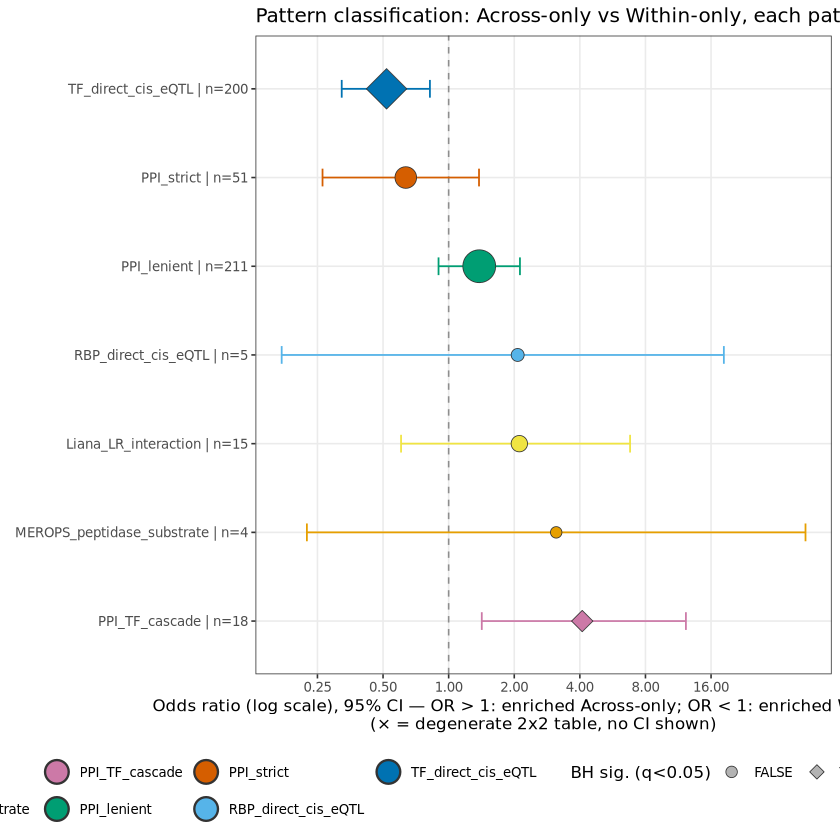

In [35]:
p_pattern_or <- ggplot(pattern_or_results, aes(x = odds_ratio, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(
    data = pattern_or_results[status == "ok"],
    aes(xmin = ci_low, xmax = ci_high, color = pattern),
    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE
  ) +
  geom_point(
    data = pattern_or_results[status == "ok"],
    aes(size = n_in_pattern, fill = pattern, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = pattern_or_results[status == "degenerate_table"],
    aes(fill = pattern), x = 1, shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = pattern_colors, name = "Pattern") +
  scale_color_manual(values = pattern_colors, guide = "none") +
  scale_size_continuous(name = "Factors in pattern", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1, nrow = 2),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2, nrow = 1)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  labs(
    x = "Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
    y = NULL,
    title = "Pattern classification: Across-only vs Within-only, each pattern vs. other classified patterns"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 8, lineheight = 0.8),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 8)
  )


p_pattern_or

In [36]:
pattern_comp_data <- rbind(
  pattern_or_results[status == "ok", .(row_label, n_total_pos = n_in_pattern,
                                         composition_type = "Within", pct = 100 * within_in_pattern / n_in_pattern)],
  pattern_or_results[status == "ok", .(row_label, n_total_pos = n_in_pattern,
                                         composition_type = "Across", pct = 100 * across_in_pattern / n_in_pattern)]
)

## Degenerate-table patterns get an explicit NA marker, same convention used
## throughout this notebook for "tested but structurally uninformative" rows
deg_rows <- pattern_or_results[status == "degenerate_table", .(row_label)]
if (nrow(deg_rows) > 0) {
  pattern_comp_data <- rbind(pattern_comp_data,
    deg_rows[, .(row_label, n_total_pos = NA_integer_, composition_type = "Within", pct = NA_real_)],
    deg_rows[, .(row_label, n_total_pos = NA_integer_, composition_type = "Across", pct = NA_real_)]
  )
}

pattern_comp_data[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

cat("Rows per composition_type:\n")
print(table(pattern_comp_data$composition_type))

Rows per composition_type:

Within Across 
     7      7 


In [37]:
p_pattern_comp <- ggplot(pattern_comp_data, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(
    data = unique(pattern_comp_data[!is.na(n_total_pos), .(row_label, n_total_pos)]),
    aes(x = 50, y = row_label, label = n_total_pos),
    inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold"
  ) +
  geom_text(
    data = unique(pattern_comp_data[is.na(pct), .(row_label)]),
    aes(x = 50, y = row_label), label = "NA",
    inherit.aes = FALSE, color = "grey40", size = 3, fontface = "italic"
  ) +
  scale_fill_manual(values = within_across_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 50, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = levels(pattern_or_results$row_label)) +
  labs(x = "% Within vs Across", y = NULL) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        panel.grid.minor = element_blank(), legend.position = "bottom")

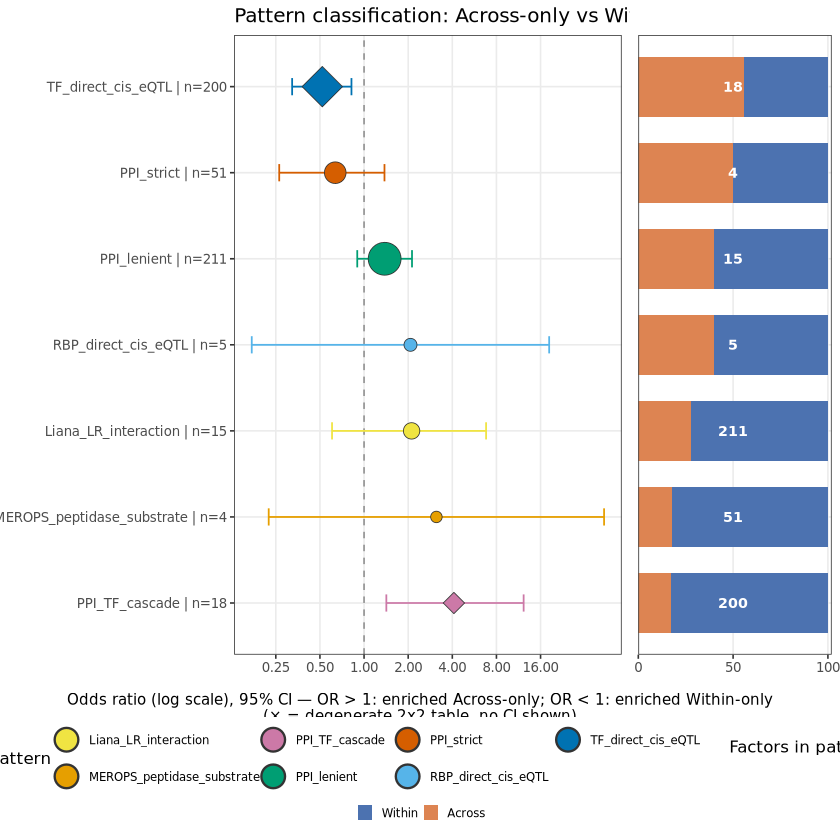

In [38]:
p_pattern_or_no_xlab <- p_pattern_or + labs(x = NULL)
p_pattern_comp_no_xlab <- p_pattern_comp + labs(x = NULL)

pattern_main_grid <- plot_grid(
  strip_legend(p_pattern_or_no_xlab), strip_legend(p_pattern_comp_no_xlab),
  ncol = 2, align = "h", axis = "tb", rel_widths = c(3, 1)
)

pattern_xlab_grob <- ggdraw() +
  draw_label("Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
             size = 9, fontface = "plain")

pattern_legend_or <- get_legend(
  p_pattern_or + guides(fill = guide_legend(nrow = 2, override.aes = list(size = 6, shape = 21, colour = "grey20")),
                         shape = guide_legend(nrow = 1, override.aes = list(size = 3, fill = "grey70"))) +
    theme(legend.position = "bottom", legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_comp <- get_legend(
  p_pattern_comp + guides(fill = guide_legend(nrow = 1)) +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_combined <- plot_grid(pattern_legend_or, pattern_legend_comp, ncol = 1)

p_pattern_combined <- plot_grid(
  pattern_main_grid, pattern_xlab_grob, pattern_legend_combined,
  ncol = 1, rel_heights = c(10, 0.7, 1.6)
)


p_pattern_combined

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Odds ratio (log scale), 95% CI — OR > 1: enriched Across-only; OR < 1: enriched Within-only' in 'mbcsToSbcs': - substituted for — (U+2014)”


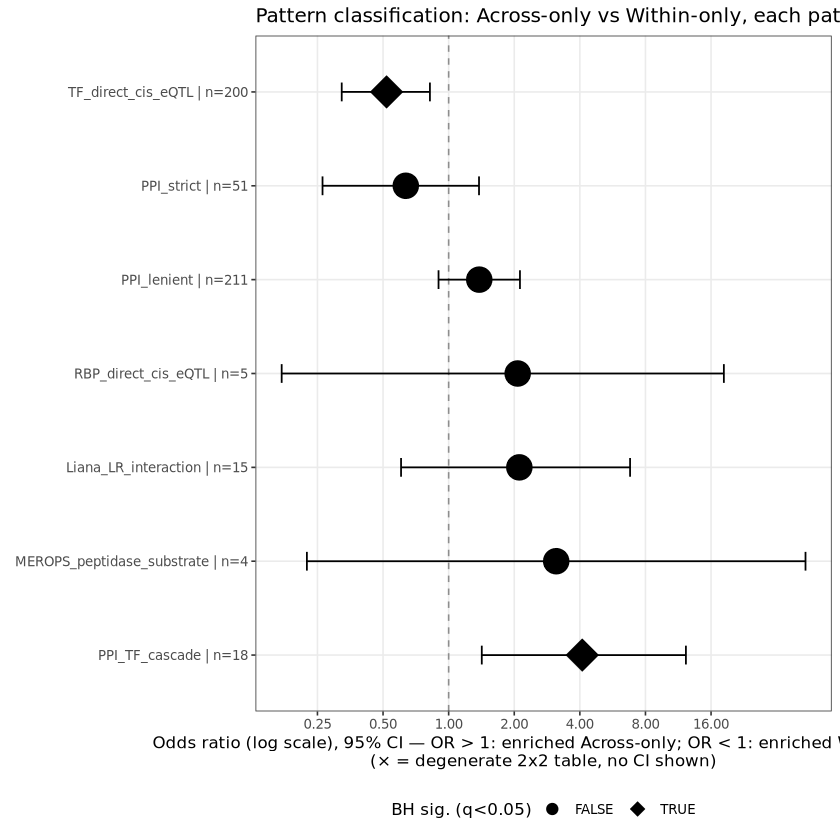

In [41]:
p_pattern_or <- ggplot(pattern_or_results, aes(x = odds_ratio, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(
    data = pattern_or_results[status == "ok"],
    aes(xmin = ci_low, xmax = ci_high),
    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE, color = "black"
  ) +
  geom_point(
    data = pattern_or_results[status == "ok"],
    aes(shape = sig_BH_05),
    fill = "black", color = "black", size = 7, stroke = 0.35
  ) +
  geom_point(
    data = pattern_or_results[status == "degenerate_table"],
    x = 1, shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  guides(shape = guide_legend(override.aes = list(size = 3, fill = "black"), order = 1)) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  labs(
    x = "Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
    y = NULL,
    title = "Pattern classification: Across-only vs Within-only, each pattern vs. other classified patterns"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 8, lineheight = 0.8),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 8)
  )

ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.png"), p_pattern_or,
       width = 202, height = 130, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.pdf"), p_pattern_or,
       width = 202, height = 130, units = "mm", bg = "white")

p_pattern_or

In [48]:
total_pattern_programs_n <- cis_trans_network_bundle$plot_metadata$total_n
cat("Total cis/trans network programs (Source_module, Source_gene, program):", total_pattern_programs_n, "\n")

pattern_or_results[, facet_label := paste0("Across vs Within (total N = ", total_pattern_programs_n, ")")]

Total cis/trans network programs (Source_module, Source_gene, program): 3167 


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Odds ratio (log scale), 95% CI — OR > 1: enriched Across-only; OR < 1: enriched Within-only' in 'mbcsToSbcs': - substituted for — (U+2014)”


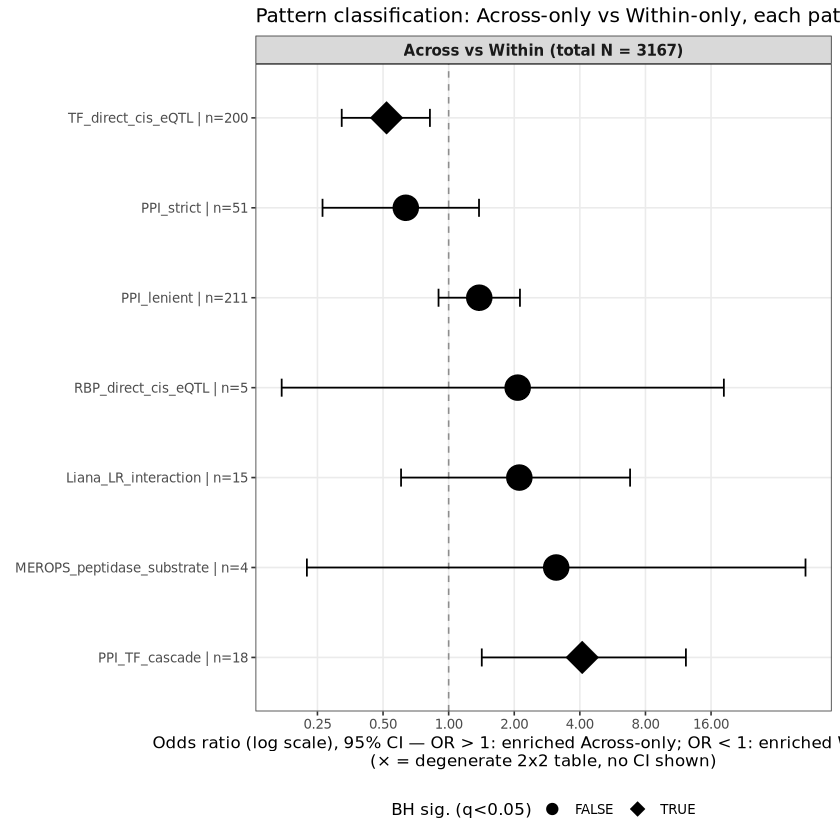

In [49]:
p_pattern_or <- ggplot(pattern_or_results, aes(x = odds_ratio, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(
    data = pattern_or_results[status == "ok"],
    aes(xmin = ci_low, xmax = ci_high),
    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE, color = "black"
  ) +
  geom_point(
    data = pattern_or_results[status == "ok"],
    aes(shape = sig_BH_05),
    fill = "black", color = "black", size = 7, stroke = 0.35
  ) +
  geom_point(
    data = pattern_or_results[status == "degenerate_table"],
    x = 1, shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  guides(shape = guide_legend(override.aes = list(size = 3, fill = "black"), order = 1)) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(cols = vars(facet_label)) +
  labs(
    x = "Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
    y = NULL,
    title = "Pattern classification: Across-only vs Within-only, each pattern vs. other classified patterns"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 8, lineheight = 0.8),
    panel.grid.minor = element_blank(),
    strip.text = element_text(size = 9, face = "bold"),
    legend.position = "bottom",
    legend.text = element_text(size = 8)
  )

ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.png"), p_pattern_or,
       width = 202, height = 130, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.pdf"), p_pattern_or,
       width = 202, height = 130, units = "mm", bg = "white")

p_pattern_or

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Odds ratio (log scale), 95% CI — OR > 1: enriched Across-only; OR < 1: enriched Within-only' in 'mbcsToSbcs': - substituted for — (U+2014)”


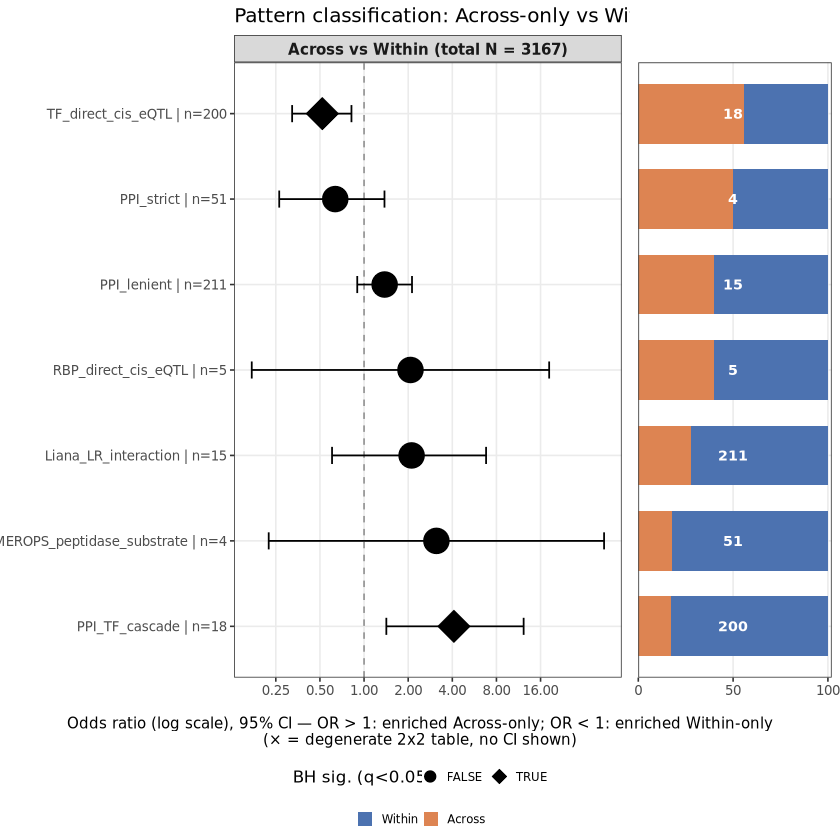

In [50]:
p_pattern_or_no_xlab <- p_pattern_or + labs(x = NULL)
p_pattern_comp_no_xlab <- p_pattern_comp + labs(x = NULL)

pattern_main_grid <- plot_grid(
  strip_legend(p_pattern_or_no_xlab), strip_legend(p_pattern_comp_no_xlab),
  ncol = 2, align = "h", axis = "tb", rel_widths = c(3, 1)
)

pattern_xlab_grob <- ggdraw() +
  draw_label("Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
             size = 9, fontface = "plain")

pattern_legend_or <- get_legend(
  p_pattern_or + guides(shape = guide_legend(nrow = 1, override.aes = list(size = 3, fill = "black"))) +
    theme(legend.position = "bottom", legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_comp <- get_legend(
  p_pattern_comp + guides(fill = guide_legend(nrow = 1)) +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_combined <- plot_grid(pattern_legend_or, pattern_legend_comp, ncol = 1)

p_pattern_combined <- plot_grid(
  pattern_main_grid, pattern_xlab_grob, pattern_legend_combined,
  ncol = 1, rel_heights = c(10, 0.7, 1.2)
)

ggsave(paste0(global_plots_dir, "pattern_within_across_combined.png"), p_pattern_combined,
       width = 202, height = 150, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "pattern_within_across_combined.pdf"), p_pattern_combined,
       width = 202, height = 150, units = "mm", bg = "white")

p_pattern_combined

In [92]:
## composition_universe was never loaded here (only pattern_or_results was) -
## recover its size directly: n_in_pattern + n_background is the same total
## for every pattern (shared background universe), so any row gives it.
totals_check <- pattern_or_results[, .(total = n_in_pattern + n_background)]
cat("n_in_pattern + n_background per row (should all be identical):\n")
print(unique(totals_check$total))

total_pattern_programs_n <- unique(totals_check$total)
stopifnot(length(total_pattern_programs_n) == 1)  # confirm it really is constant across patterns
cat("Total programs (Source_module, Source_gene, program) in the pattern comparison universe:", total_pattern_programs_n, "\n")

pattern_or_results[, facet_label := paste0("Across vs Within (total N = ", total_pattern_programs_n, ")")]

n_in_pattern + n_background per row (should all be identical):
[1] 503
Total programs (Source_module, Source_gene, program) in the pattern comparison universe: 503 


In [93]:
## Strip " | n=<number>" from row_label everywhere it's used (pattern name
## alone, going forward), while preserving the already-correct sort order.
pattern_or_results[, row_label := sub(" \\| n=\\d+$", "", as.character(row_label))]
pattern_or_results[, row_label := factor(row_label, levels = sub(" \\| n=\\d+$", "", levels(pattern_or_results$row_label)))]

pattern_comp_data[, row_label := sub(" \\| n=\\d+$", "", as.character(row_label))]

In [94]:
total_pattern_programs_n <- cis_trans_network_bundle$plot_metadata$total_n
cat("Total cis/trans network programs (Source_module, Source_gene, program):", total_pattern_programs_n, "\n")

pattern_or_results[, facet_label := paste0("Across-only vs Within-only networks")]

Total cis/trans network programs (Source_module, Source_gene, program): 3167 


In [103]:
## Capture the OLD (correctly-ordered) levels BEFORE modifying row_label at all
old_row_label_order <- levels(pattern_or_results$row_label)
new_row_label_order <- sub(" \\| n=\\d+$", "", old_row_label_order)

## Now strip the suffix from the actual values
pattern_or_results[, row_label := sub(" \\| n=\\d+$", "", as.character(row_label))]
pattern_or_results[, row_label := factor(row_label, levels = new_row_label_order)]

pattern_comp_data[, row_label := sub(" \\| n=\\d+$", "", as.character(row_label))]

cat("Levels after fix:\n")
print(levels(pattern_or_results$row_label))
cat("\nAny NA row_label values (should be 0):\n")
print(sum(is.na(pattern_or_results$row_label)))

Levels after fix:
[1] "TF_direct_cis_eQTL"         "PPI_strict"                
[3] "PPI_lenient"                "RBP_direct_cis_eQTL"       
[5] "Liana_LR_interaction"       "MEROPS_peptidase_substrate"
[7] "PPI_TF_cascade"            

Any NA row_label values (should be 0):
[1] 0


In [104]:
## Rebuild row_label from scratch (pattern name only, no "| n=" suffix this
## time), and reconstruct the same sort order as originally derived:
## degenerate-table patterns first, then "ok" patterns sorted by odds_ratio ascending.
pattern_or_results[, row_label := pattern]  # plain pattern name, no suffix

ok_order  <- pattern_or_results[status == "ok"][order(odds_ratio)]$row_label
deg_order <- pattern_or_results[status == "degenerate_table"]$row_label
new_row_label_order <- c(deg_order, ok_order)

pattern_or_results[, row_label := factor(row_label, levels = new_row_label_order)]

cat("Levels after rebuild:\n")
print(levels(pattern_or_results$row_label))
cat("\nAny NA row_label values (should be 0):\n")
print(sum(is.na(pattern_or_results$row_label)))

## pattern_comp_data was built from the OLD row_label (with "| n=" suffix)
## in an earlier cell - safest to rebuild it fresh from pattern_or_results
## rather than trying to patch the stale version.
pattern_comp_data <- rbind(
  pattern_or_results[status == "ok", .(row_label, n_total_pos = n_in_pattern,
                                         composition_type = "Within", pct = 100 * within_in_pattern / n_in_pattern)],
  pattern_or_results[status == "ok", .(row_label, n_total_pos = n_in_pattern,
                                         composition_type = "Across", pct = 100 * across_in_pattern / n_in_pattern)]
)

deg_rows <- pattern_or_results[status == "degenerate_table", .(row_label)]
if (nrow(deg_rows) > 0) {
  pattern_comp_data <- rbind(pattern_comp_data,
    deg_rows[, .(row_label, n_total_pos = NA_integer_, composition_type = "Within", pct = NA_real_)],
    deg_rows[, .(row_label, n_total_pos = NA_integer_, composition_type = "Across", pct = NA_real_)]
  )
}
pattern_comp_data[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

cat("Rows per composition_type:\n")
print(table(pattern_comp_data$composition_type))

Levels after rebuild:
[1] "TF_direct_cis_eQTL"         "PPI_strict"                
[3] "PPI_lenient"                "RBP_direct_cis_eQTL"       
[5] "Liana_LR_interaction"       "MEROPS_peptidase_substrate"
[7] "PPI_TF_cascade"            

Any NA row_label values (should be 0):
[1] 0
Rows per composition_type:

Within Across 
     7      7 


In [105]:
cis_trans_network_bundle <- readRDS(paste0(master_dir, "Factor_ER/cis_trans_network_results_bundle.rds"))

In [106]:
## Explicit top-to-bottom order, as specified - replaces the earlier
## OR-magnitude-sorted derivation entirely.
row_order_top_to_bottom_pattern <- c(
  "TF_direct_cis_eQTL",
  "RBP_direct_cis_eQTL",
  "Liana_LR_interaction",
  "MEROPS_peptidase_substrate",
  "PPI_TF_cascade",
  "PPI_lenient",
  "PPI_strict"
)

cat("Patterns in data NOT covered by the explicit order (should be empty):\n")
print(setdiff(unique(pattern_or_results$pattern), row_order_top_to_bottom_pattern))
stopifnot(length(setdiff(unique(pattern_or_results$pattern), row_order_top_to_bottom_pattern)) == 0)

pattern_or_results[, row_label := factor(pattern, levels = row_order_top_to_bottom_pattern)]
pattern_comp_data[, row_label := factor(as.character(row_label), levels = row_order_top_to_bottom_pattern)]

Patterns in data NOT covered by the explicit order (should be empty):
character(0)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Odds ratio (log scale), 95% CI — OR > 1: enriched Across-only; OR < 1: enriched Within-only' in 'mbcsToSbcs': - substituted for — (U+2014)”


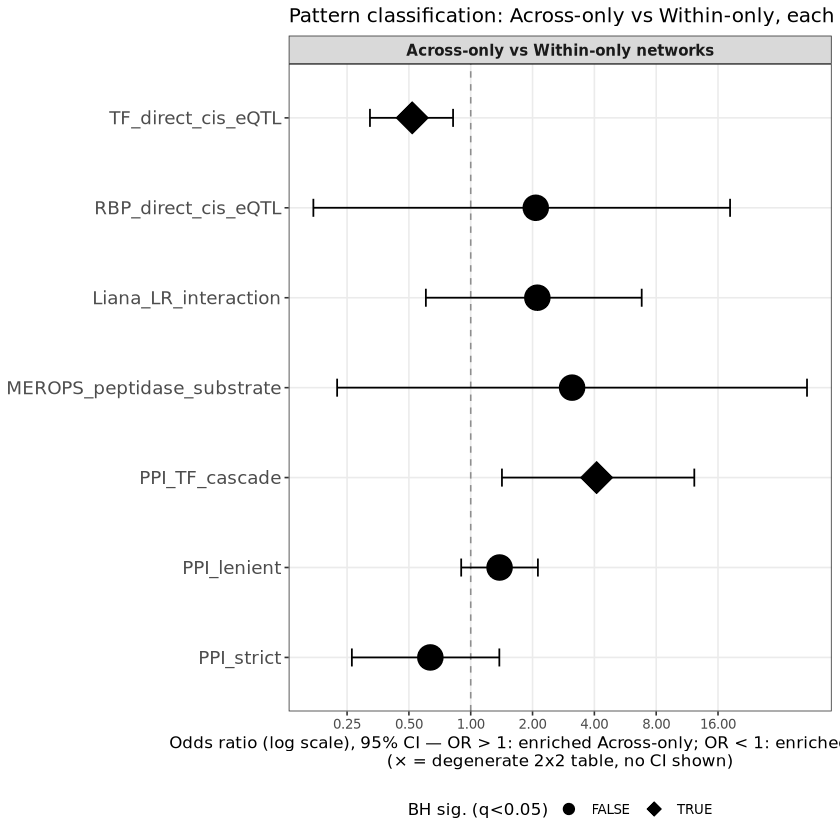

In [107]:
p_pattern_or <- ggplot(pattern_or_results, aes(x = odds_ratio, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(
    data = pattern_or_results[status == "ok"],
    aes(xmin = ci_low, xmax = ci_high),
    orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE, color = "black"
  ) +
  geom_point(
    data = pattern_or_results[status == "ok"],
    aes(shape = sig_BH_05),
    fill = "black", color = "black", size = 7, stroke = 0.35
  ) +
  geom_point(
    data = pattern_or_results[status == "degenerate_table"],
    x = 1, shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  guides(shape = guide_legend(override.aes = list(size = 3, fill = "black"), order = 1)) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(cols = vars(facet_label)) +
  labs(
    x = "Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
    y = NULL,
    title = "Pattern classification: Across-only vs Within-only, each pattern vs. other classified patterns"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 11, lineheight = 0.8),
    panel.grid.minor = element_blank(),
    strip.text = element_text(size = 9, face = "bold"),
    legend.position = "bottom",
    legend.text = element_text(size = 8)
  )

ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.png"), p_pattern_or,
       width = 202, height = 130, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "pattern_within_across_odds_ratio.pdf"), p_pattern_or,
       width = 202, height = 130, units = "mm", bg = "white")

p_pattern_or

In [108]:
p_pattern_comp <- ggplot(pattern_comp_data, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(
    data = unique(pattern_comp_data[!is.na(n_total_pos), .(row_label, n_total_pos)]),
    aes(x = 50, y = row_label, label = n_total_pos),
    inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold"
  ) +
  geom_text(
    data = unique(pattern_comp_data[is.na(pct), .(row_label)]),
    aes(x = 50, y = row_label), label = "NA",
    inherit.aes = FALSE, color = "grey40", size = 3, fontface = "italic"
  ) +
  scale_fill_manual(values = within_across_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 50, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = rev(levels(pattern_or_results$row_label))) +
  labs(x = "% Within vs Across", y = NULL) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        panel.grid.minor = element_blank(), legend.position = "bottom")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Odds ratio (log scale), 95% CI — OR > 1: enriched Across-only; OR < 1: enriched Within-only' in 'mbcsToSbcs': - substituted for — (U+2014)”


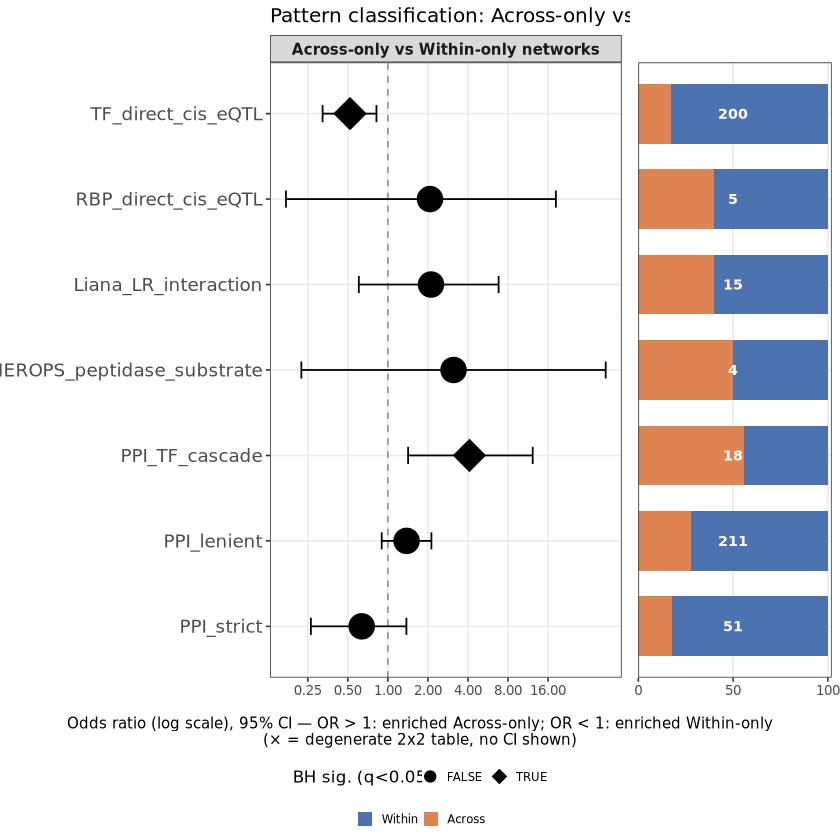

In [109]:
p_pattern_or_no_xlab <- p_pattern_or + labs(x = NULL)
p_pattern_comp_no_xlab <- p_pattern_comp + labs(x = NULL)

pattern_main_grid <- plot_grid(
  strip_legend(p_pattern_or_no_xlab), strip_legend(p_pattern_comp_no_xlab),
  ncol = 2, align = "h", axis = "tb", rel_widths = c(3, 1)
)

pattern_xlab_grob <- ggdraw() +
  draw_label("Odds ratio (log scale), 95% CI \u2014 OR > 1: enriched Across-only; OR < 1: enriched Within-only\n(\u00d7 = degenerate 2x2 table, no CI shown)",
             size = 9, fontface = "plain")

pattern_legend_or <- get_legend(
  p_pattern_or + guides(shape = guide_legend(nrow = 1, override.aes = list(size = 3, fill = "black"))) +
    theme(legend.position = "bottom", legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_comp <- get_legend(
  p_pattern_comp + guides(fill = guide_legend(nrow = 1)) +
    theme(legend.position = "bottom", legend.title = element_blank(),
          legend.text = element_text(size = 7), legend.key.size = unit(0.35, "cm"))
)
pattern_legend_combined <- plot_grid(pattern_legend_or, pattern_legend_comp, ncol = 1)

p_pattern_combined <- plot_grid(
  pattern_main_grid, pattern_xlab_grob, pattern_legend_combined,
  ncol = 1, rel_heights = c(10, 0.7, 1.2)
)

ggsave(paste0(global_plots_dir, "pattern_within_across_combined.png"), p_pattern_combined,
       width = 202, height = 150, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(global_plots_dir, "pattern_within_across_combined.pdf"), p_pattern_combined,
       width = 202, height = 150, units = "mm", bg = "white")

p_pattern_combined